<a href="https://colab.research.google.com/github/leonardeugenia-hash/TGF2026/blob/main/ingenieria_del_dato/datos2_contextuales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

---
## 1. HÁBITOS DE ESCUCHA


In [ ]:
def leer_habito_escucha(path, year_label):
    """
    Lee un archivo de hábitos de escucha del Ministerio de Cultura.
    Extrae el % TOTAL que escucha música todos los días.
    """
    df = pd.read_excel(path, sheet_name='tabla-0', header=None, engine='openpyxl')
    mask_total = df[0].astype(str).str.strip().str.upper() == 'TOTAL'
    fila_total = df[mask_total]
    if fila_total.empty:
        print(f"  ⚠️  No se encontró fila TOTAL en {path}")
        return None
    pct = float(fila_total.iloc[0, 1])
    print(f"  ✅ {year_label}: pct_escucha_diaria TOTAL = {pct}%")
    return pct


def styled_table(df, caption=''):
    return (
        df.style
        .set_caption(caption)
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]},
            {'selector': 'thead th',
             'props': [('background-color', '#1a3a5c'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', '#f0f4f8')]},
            {'selector': 'tbody tr:hover',
             'props': [('background-color', '#d6e4f0')]},
            {'selector': 'td, th',
             'props': [('padding', '6px 12px'), ('text-align', 'center')]},
        ])
        .format(precision=2)
    )


print("=" * 50)
print("HÁBITOS DE ESCUCHA")
print("=" * 50)

habitos_raw = {
    2010: leer_habito_escucha('2010_2011_habito_escucha_culturagob.xlsx', '2010-2011'),
    2014: leer_habito_escucha('2014_2015_habito_escucha_culturagob.xlsx', '2014-2015'),
    2018: leer_habito_escucha('2018_2019_habito_escucha_culturagob.xlsx', '2018-2019'),
    2021: leer_habito_escucha('2021_2022_habito_escucha_culturagob.xlsx', '2021-2022'),
    2024: leer_habito_escucha('2024_2025_habito_escucha_culturagob.xlsx', '2024-2025'),
}

habitos_puntos = {
    2010: habitos_raw[2010], 2011: habitos_raw[2010],
    2014: habitos_raw[2014], 2015: habitos_raw[2014],
    2018: habitos_raw[2018], 2019: habitos_raw[2018],
    2021: habitos_raw[2021], 2022: habitos_raw[2021],
    2024: habitos_raw[2024],
}

df_habitos = pd.DataFrame(list(habitos_puntos.items()), columns=['year', 'pct_escucha_diaria'])
df_habitos = df_habitos.sort_values('year').reset_index(drop=True)

years_completos = pd.DataFrame({'year': range(2010, 2025)})
df_habitos = years_completos.merge(df_habitos, on='year', how='left')
df_habitos['pct_escucha_diaria'] = df_habitos['pct_escucha_diaria'].interpolate(method='linear').round(2)

display(styled_table(df_habitos, 'Serie interpolada — Hábito de escucha diaria (%)').format({'year': '{:.0f}', 'pct_escucha_diaria': '{:.2f}'}))


HÁBITOS DE ESCUCHA
  ✅ 2010-2011: pct_escucha_diaria TOTAL = 64.8%
  ✅ 2014-2015: pct_escucha_diaria TOTAL = 65.4%
  ✅ 2018-2019: pct_escucha_diaria TOTAL = 70.6%
  ✅ 2021-2022: pct_escucha_diaria TOTAL = 64.7%
  ✅ 2024-2025: pct_escucha_diaria TOTAL = 56.7%


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,year,pct_escucha_diaria
0,2010,64.80
1,2011,64.80
2,2012,65.00
3,2013,65.20
4,2014,65.40
5,2015,65.40
6,2016,67.13
7,2017,68.87
8,2018,70.60
9,2019,70.60


---
## 2. SUSCRIPCIONES A PLATAFORMAS DIGITALES DE MÚSICA
Fuente: Encuesta de Hábitos y Prácticas Culturales — Ministerio de Cultura  
Variables clave: `pct_suscripcion_total`, `pct_suscripcion_pago`

In [ ]:
def leer_suscripcion(path, year_label):
    """
    Lee un archivo de suscripciones del Ministerio de Cultura.
    Extrae el % TOTAL suscrito y % suscripciones de pago.
    """
    df = pd.read_excel(path, sheet_name='tabla-0', header=None, engine='openpyxl')
    mask_total = df[0].astype(str).str.strip().str.upper() == 'TOTAL'
    fila_total = df[mask_total]
    if fila_total.empty:
        mask_15_19 = df[0].astype(str).str.contains('15 a 19', na=False)
        mask_20_24 = df[0].astype(str).str.contains('20 a 24', na=False)
        mask_25_34 = df[0].astype(str).str.contains('25 a 34', na=False)
        filas = df[mask_15_19 | mask_20_24 | mask_25_34]
        if filas.empty:
            print(f"  ⚠️  No se pudo extraer dato de {path}")
            return None, None
        total = filas.iloc[:, 1].astype(float).mean().round(1)
        pago  = filas.iloc[:, 3].astype(float).mean().round(1)
        print(f"  ⚠️  {year_label}: sin TOTAL — estimado como media tramos 15-34: suscripcion_total={total}%, suscripcion_pago={pago}%")
        return total, pago
    total = float(fila_total.iloc[0, 1])
    pago  = float(fila_total.iloc[0, 3])
    print(f"  ✅ {year_label}: suscripcion_total={total}%, suscripcion_pago={pago}%")
    return total, pago


print("=" * 50)
print("SUSCRIPCIONES A PLATAFORMAS")
print("=" * 50)

suscripcion_raw = {}
t, p = leer_suscripcion('2018_2019_suscripcion_culturagob.xlsx', '2018-2019')
suscripcion_raw[2018] = (t, p)
suscripcion_raw[2019] = (t, p)

t, p = leer_suscripcion('2021_2022_suscripcion_culturagob.xlsx', '2021-2022')
suscripcion_raw[2021] = (t, p)
suscripcion_raw[2022] = (t, p)

t, p = leer_suscripcion('2024_2025_suscripcion_culturagob.xlsx', '2024-2025')
suscripcion_raw[2024] = (t, p)

suscripcion_raw[2010] = (0.0, 0.0)
suscripcion_raw[2013] = (2.0, 1.0)

df_suscripcion = pd.DataFrame(
    [(y, v[0], v[1]) for y, v in sorted(suscripcion_raw.items())],
    columns=['year', 'pct_suscripcion_total', 'pct_suscripcion_pago']
)

years_completos = pd.DataFrame({'year': range(2010, 2025)})
df_suscripcion = years_completos.merge(df_suscripcion, on='year', how='left')
df_suscripcion['pct_suscripcion_total'] = df_suscripcion['pct_suscripcion_total'].interpolate(method='linear').round(2)
df_suscripcion['pct_suscripcion_pago']  = df_suscripcion['pct_suscripcion_pago'].interpolate(method='linear').round(2)

display(styled_table(df_suscripcion, 'Serie interpolada — Suscripciones a plataformas digitales (%)').format({'year': '{:.0f}', 'pct_suscripcion_total': '{:.2f}', 'pct_suscripcion_pago': '{:.2f}'}))


SUSCRIPCIONES A PLATAFORMAS
  ✅ 2018-2019: suscripcion_total=21.4%, suscripcion_pago=10.7%
  ⚠️  2021-2022: sin TOTAL — estimado como media tramos 15-34: suscripcion_total=55.9%, suscripcion_pago=29.2%
  ✅ 2024-2025: suscripcion_total=48.0%, suscripcion_pago=24.8%


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,year,pct_suscripcion_total,pct_suscripcion_pago
0,2010,0.00,0.00
1,2011,0.67,0.33
2,2012,1.33,0.67
3,2013,2.00,1.00
4,2014,5.88,2.94
5,2015,9.76,4.88
6,2016,13.64,6.82
7,2017,17.52,8.76
8,2018,21.40,10.70
9,2019,21.40,10.70


---
## 4. GOOGLE TRENDS


In [ ]:
def leer_google_trends(path, nombre_col):
    df = pd.read_csv(path, skiprows=1, encoding='utf-8')
    df.columns = ['month', 'trend_index']
    df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
    df['year'] = df['month'].dt.year
    df['trend_index'] = pd.to_numeric(df['trend_index'], errors='coerce')
    cobertura = df.groupby('year')['trend_index'].count().rename('meses_validos')
    nulos_por_año = df.groupby('year')['trend_index'].apply(lambda x: x.isnull().sum()).rename('meses_nulos')
    df_anual = df.groupby('year')['trend_index'].mean().round(1).reset_index()
    df_anual.columns = ['year', nombre_col]
    df_anual = df_anual.merge(cobertura, on='year').merge(nulos_por_año, on='year')
    baja_cobertura = df_anual[df_anual['meses_validos'] < 6]
    if not baja_cobertura.empty:
        print(f"  ⚠️  [{nombre_col}] Años con cobertura < 50%:")
        display(styled_table(baja_cobertura[['year', 'meses_validos', 'meses_nulos']], 'Años con baja cobertura').format({'year': '{:.0f}'}))
    return df_anual[['year', nombre_col]], df_anual[['year', 'meses_validos', 'meses_nulos']].rename(
        columns={'meses_validos': f'cobertura_{nombre_col}', 'meses_nulos': f'nulos_{nombre_col}'}
    )


print("=" * 50)
print("GOOGLE TRENDS")
print("=" * 50)

df_trends_premium,  cob_premium   = leer_google_trends('webtrends_spotifypremium_2010_2024.csv',  'trend_spotify_premium')
df_trends_streaming, cob_streaming = leer_google_trends('webtrends_streamingmusic_2010_2024.csv', 'trend_streaming_music')

df_trends_premium   = df_trends_premium[(df_trends_premium['year'] >= 2010) & (df_trends_premium['year'] <= 2024)]
df_trends_streaming = df_trends_streaming[(df_trends_streaming['year'] >= 2010) & (df_trends_streaming['year'] <= 2024)]

df_trends = df_trends_premium.merge(df_trends_streaming, on='year', how='outer').sort_values('year').reset_index(drop=True)

df_cobertura_trends = cob_premium.merge(cob_streaming, on='year', how='outer')
display(styled_table(df_cobertura_trends, 'Cobertura mensual por año — Google Trends').format({'year': '{:.0f}'}))

nulos_trends = df_trends.isnull().sum()
if nulos_trends.sum() > 0:
    print(f"\n⚠️  NaN residuales en trends: {nulos_trends[nulos_trends > 0].to_dict()}")
    df_trends = df_trends.fillna(df_trends.mean(numeric_only=True).round(1))
    print("   → Imputados con la media global de la serie.")
else:
    print("\n✅ Sin NaN en trends tras agregación anual.")

display(styled_table(df_trends, 'Serie anual — Google Trends').format({'year': '{:.0f}'}))


GOOGLE TRENDS


,year,cobertura_trend_spotify_premium,nulos_trend_spotify_premium,cobertura_trend_streaming_music,nulos_trend_streaming_music
0,2010,12,0,12,0
1,2011,12,0,12,0
2,2012,12,0,12,0
3,2013,12,0,12,0
4,2014,12,0,12,0
5,2015,12,0,12,0
6,2016,12,0,12,0
7,2017,12,0,12,0
8,2018,12,0,12,0
9,2019,12,0,12,0



✅ Sin NaN en trends tras agregación anual.


,year,trend_spotify_premium,trend_streaming_music
0,2010,8.300000,56.200000
1,2011,17.200000,30.600000
2,2012,19.200000,37.900000
3,2013,17.700000,45.900000
4,2014,18.200000,35.200000
5,2015,26.700000,56.200000
6,2016,37.100000,40.300000
7,2017,49.600000,26.300000
8,2018,60.400000,30.000000
9,2019,64.200000,24.200000


---
## 5. VALIDACIÓN INDIVIDUAL DE CADA DATASET

In [ ]:
print("=" * 55)
print("VALIDACIÓN")
print("=" * 55)

datasets = {
    'df_habitos':     df_habitos,
    'df_suscripcion': df_suscripcion,
    'df_trends':      df_trends,
}

resumen_validacion = []
for name, df in datasets.items():
    nulos = df.isnull().sum().sum()
    resumen_validacion.append({
        'Dataset': name,
        'Filas': df.shape[0],
        'Columnas': df.shape[1],
        'Año min': df['year'].min(),
        'Año max': df['year'].max(),
        'Nulos': nulos if nulos > 0 else '0',
    })

df_validacion = pd.DataFrame(resumen_validacion)
display(styled_table(df_validacion, 'Validación individual de datasets').format(precision=0))


VALIDACIÓN


,Dataset,Filas,Columnas,Año min,Año max,Nulos
0,df_habitos,15,2,2010,2024,0
1,df_suscripcion,15,3,2010,2024,0
2,df_trends,15,3,2010,2024,0


---
## 6. INTEGRACIÓN: MERGE DE TODOS LOS DATASETS EN UNO

In [ ]:
print("=" * 55)
print("MERGE FINAL")
print("=" * 55)

df_contextual = (
    df_habitos
    .merge(df_suscripcion, on='year', how='left')
    .merge(df_trends,      on='year', how='left')
)

print(f"Shape tras merge: {df_contextual.shape}")

nulos_post_merge = df_contextual.isnull().sum()
cols_con_nulos = nulos_post_merge[nulos_post_merge > 0].index.tolist()
if cols_con_nulos:
    print(f"\n⚠️  Columnas con nulos: {cols_con_nulos}")
    print("   → Estrategia: interpolación lineal para series temporales continuas.")
    for col in cols_con_nulos:
        df_contextual[col] = (
            df_contextual[col]
            .interpolate(method='linear')
            .fillna(method='bfill')
            .fillna(method='ffill')
            .round(2)
        )
    print(f"   ✅ Nulos tras imputación: {df_contextual.isnull().sum().sum()}")
else:
    print("\n✅ Sin nulos tras el merge contextual.")

display(styled_table(df_contextual, 'Dataset contextual completo (2010–2024)').format({'year': '{:.0f}', 'pct_escucha_diaria': '{:.2f}', 'pct_suscripcion_total': '{:.2f}', 'pct_suscripcion_pago': '{:.2f}', 'trend_spotify_premium': '{:.2f}', 'trend_streaming_music': '{:.2f}'}))


MERGE FINAL
Shape tras merge: (15, 6)

✅ Sin nulos tras el merge contextual.


,year,pct_escucha_diaria,pct_suscripcion_total,pct_suscripcion_pago,trend_spotify_premium,trend_streaming_music
0,2010,64.80,0.00,0.00,8.30,56.20
1,2011,64.80,0.67,0.33,17.20,30.60
2,2012,65.00,1.33,0.67,19.20,37.90
3,2013,65.20,2.00,1.00,17.70,45.90
4,2014,65.40,5.88,2.94,18.20,35.20
5,2015,65.40,9.76,4.88,26.70,56.20
6,2016,67.13,13.64,6.82,37.10,40.30
7,2017,68.87,17.52,8.76,49.60,26.30
8,2018,70.60,21.40,10.70,60.40,30.00
9,2019,70.60,21.40,10.70,64.20,24.20


---
## 7. MERGE CON EL DATASET DE SPOTIFY
Unimos con `dataset_spotify_final_year.csv` del Script 1

In [ ]:
print("=" * 55)
print("MERGE CON SPOTIFY")
print("=" * 55)

df_spotify = pd.read_csv('dataset_anual_spotify_macro.csv')
df_spotify['year'] = df_spotify['year'].astype(int)
print(f"Spotify shape: {df_spotify.shape}")

df_final = df_spotify.merge(df_contextual, on='year', how='left')
print(f"Dataset final shape: {df_final.shape}")

nulos_final = df_final.isnull().sum()
cols_nulos_final = nulos_final[nulos_final > 0]

if cols_nulos_final.sum() > 0:
    print(f"\n⚠️  {cols_nulos_final.sum()} nulos detectados. Aplicando interpolación lineal.")
    cols_numericas_con_nulos = [
        c for c in cols_nulos_final.index
        if pd.api.types.is_numeric_dtype(df_final[c]) and c != 'year'
    ]
    for col in cols_numericas_con_nulos:
        df_final[col] = (
            df_final[col]
            .interpolate(method='linear')
            .fillna(method='bfill')
            .fillna(method='ffill')
            .round(4)
        )
    print(f"   ✅ Nulos restantes tras imputación: {df_final.isnull().sum().sum()}")
else:
    print("\n✅ Dataset final sin nulos.")

print("\nVista previa (primeras 5 filas):")
display(styled_table(df_final.head(), 'Vista previa — Dataset final (Spotify + Contexto)').format({'year': '{:.0f}'}))


MERGE CON SPOTIFY
Spotify shape: (15, 73)
Dataset final shape: (15, 78)

✅ Dataset final sin nulos.

Vista previa (primeras 5 filas):


,year,avg_duration,avg_popularity,std_popularity,avg_artist_popularity,explicit_ratio,n_songs,n_unique_artists,avg_years_since_rel,dominant_genre,pct_afrobeats,pct_amapiano,pct_argentine trap,pct_bachata,pct_bolero,pct_brazilian funk,pct_brazilian pop,pct_celtic rock,pct_chilean trap,pct_colombian pop,pct_corridos tumbados,pct_cuarteto,pct_dancehall,pct_dembow,pct_drill,pct_edm,pct_electro house,pct_europop,pct_flamenco,pct_flamenco pop,pct_flamenco urbano,pct_french r&b,pct_french rap,pct_house,pct_hyperpop,pct_indie,pct_k-pop,pct_kizomba,pct_latin,pct_latin afrobeats,pct_latin folk,pct_latin hip hop,pct_latin indie,pct_latin pop,pct_latin r&b,pct_latin rock,pct_laïko,pct_mariachi,pct_melbourne bounce,pct_merengue,pct_moombahton,pct_neoperreo,pct_pop,pct_rap,pct_reggaeton,pct_reggaeton chileno,pct_reggaeton mexa,pct_rkt,pct_rock en español,pct_singer-songwriter,pct_ska,pct_soft pop,pct_spanish-language reggae,pct_synthpop,pct_techengue,pct_trap latino,pct_tropical house,pct_trova,pct_unknown,pct_urbano latino,pct_villancicos,pib_per_capita,internet_access,pct_escucha_diaria,pct_suscripcion_total,pct_suscripcion_pago,trend_spotify_premium,trend_streaming_music
0,2010,226.999240,41.520000,16.423279,54.240000,0.000000,50,42,0.560000,unknown,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.140000,0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.040000,0.040000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.020000,0.440000,0.000000,0.020000,30658.742228,65.800000,64.800000,0.000000,0.000000,8.300000,56.200000
1,2011,229.118400,37.200000,17.487021,51.420000,0.020000,50,41,-0.140000,unknown,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.260000,0.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.040000,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.020000,0.480000,0.000000,0.000000,31824.621913,67.090000,64.800000,0.670000,0.330000,17.200000,30.600000
2,2012,230.686540,43.460000,17.881937,57.260000,0.000000,50,38,-0.160000,unknown,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.140000,0.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.240000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.060000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.020000,0.360000,0.000000,0.000000,28456.443815,69.810000,65.000000,1.330000,0.670000,19.200000,37.900000
3,2013,224.661920,40.280000,14.255740,54.000000,0.000000,50,40,-0.100000,unknown,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.140000,0.060000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.020000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.020000,0.080000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020000,0.440000,0.000000,0.040000,29228.846560,71.635000,65.200000,2.000000,1.000000,17.700000,45.900000
4,2014,233.362780,4

---
## 8. VISUALIZACIONES DE LAS VARIABLES CONTEXTUALES

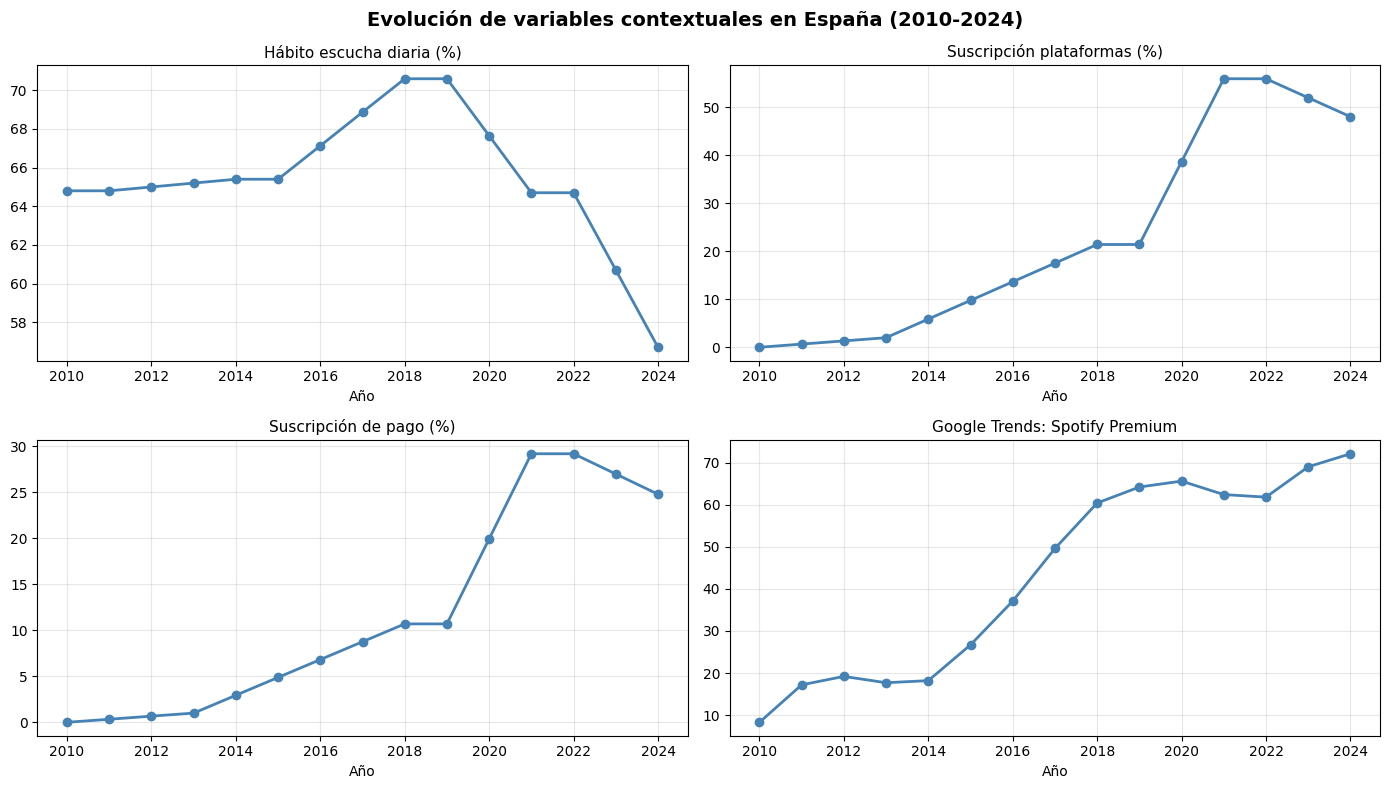

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Evolución de variables contextuales en España (2010-2024)', fontsize=14, fontweight='bold')

vars_plot = [
    ('pct_escucha_diaria',    'Hábito escucha diaria (%)',      axes[0, 0]),
    ('pct_suscripcion_total', 'Suscripción plataformas (%)',    axes[0, 1]),
    ('pct_suscripcion_pago',  'Suscripción de pago (%)',        axes[1, 0]),
    ('trend_spotify_premium', 'Google Trends: Spotify Premium', axes[1, 1]),
]

for col, title, ax in vars_plot:
    if col in df_final.columns:
        ax.plot(df_final['year'], df_final[col], marker='o', linewidth=2, color='steelblue')
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Año')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()


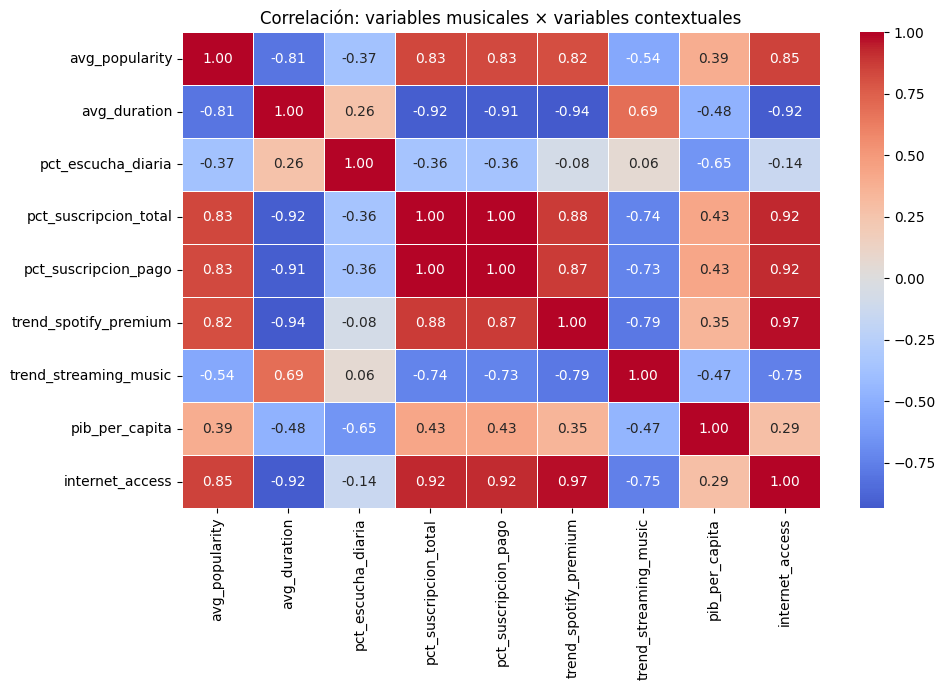

In [ ]:
# Correlación entre variables contextuales y popularidad musical
cols_corr = [
    'avg_popularity', 'avg_duration',
    'pct_escucha_diaria', 'pct_suscripcion_total', 'pct_suscripcion_pago',
    'trend_spotify_premium', 'trend_streaming_music',
    'pib_per_capita', 'internet_access'
]

# Solo usamos columnas que existan en el dataset final
cols_corr = [c for c in cols_corr if c in df_final.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df_final[cols_corr].corr(numeric_only=True),
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Correlación: variables musicales × variables contextuales', fontsize=12)
plt.tight_layout()
plt.show()

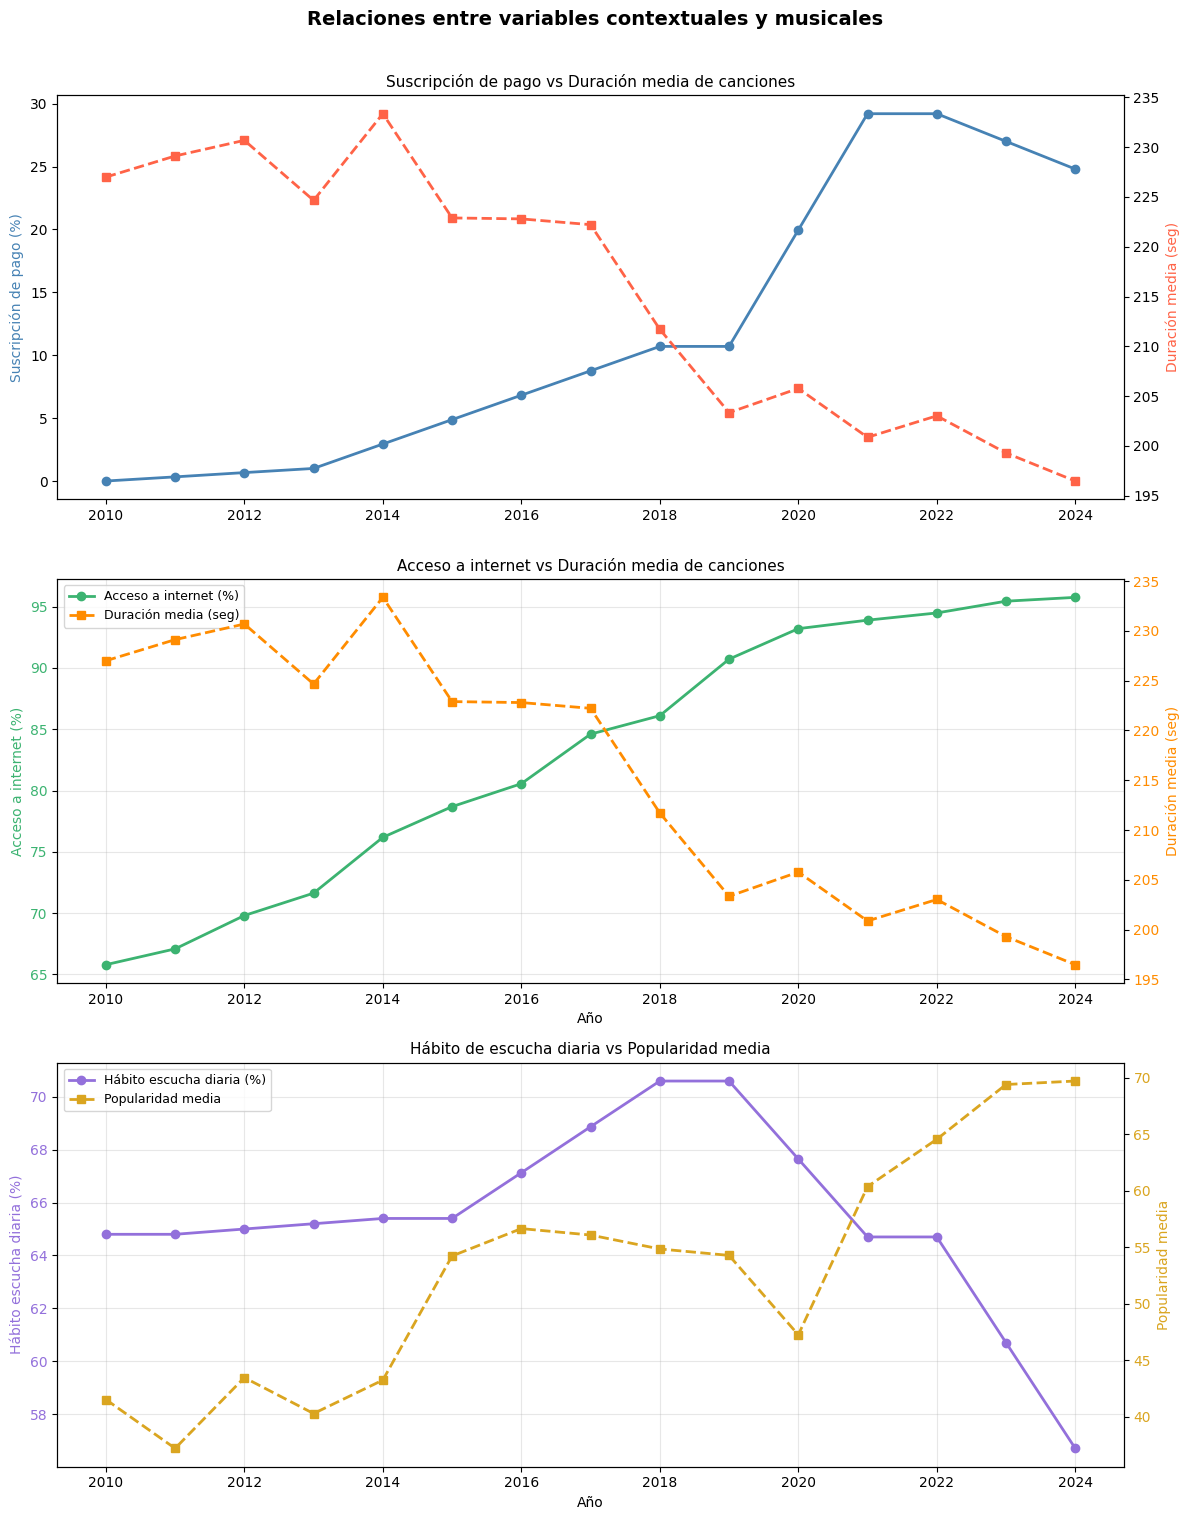

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))
fig.suptitle('Relaciones entre variables contextuales y musicales',
             fontsize=14, fontweight='bold', y=1.01)

# ── 1. Suscripción de pago vs Explicit ratio ─────────────────
ax1 = axes[0]
ax1_twin = ax1.twinx()

ax1.plot(df_final['year'], df_final['pct_suscripcion_pago'],
         color='steelblue', marker='o', linewidth=2, label='Suscripción de pago (%)')
ax1_twin.plot(df_final['year'], df_final['avg_duration'],
              color='tomato', marker='s', linewidth=2, linestyle='--', label='Duración media (seg)')

ax1.set_ylabel('Suscripción de pago (%)', color='steelblue', fontsize=10)
ax1_twin.set_ylabel('Duración media (seg)', color='tomato', fontsize=10)
ax1.set_title('Suscripción de pago vs Duración media de canciones', fontsize=11)

# ── 2. Acceso a internet vs Duración media ───────────────────
ax2 = axes[1]
ax2_twin = ax2.twinx()

ax2.plot(df_final['year'], df_final['internet_access'],
         color='mediumseagreen', marker='o', linewidth=2, label='Acceso a internet (%)')
ax2_twin.plot(df_final['year'], df_final['avg_duration'],
              color='darkorange', marker='s', linewidth=2, linestyle='--', label='Duración media (seg)')

ax2.set_ylabel('Acceso a internet (%)', color='mediumseagreen', fontsize=10)
ax2_twin.set_ylabel('Duración media (seg)', color='darkorange', fontsize=10)
ax2.set_title('Acceso a internet vs Duración media de canciones', fontsize=11)
ax2.tick_params(axis='y', labelcolor='mediumseagreen')
ax2_twin.tick_params(axis='y', labelcolor='darkorange')
ax2.set_xlabel('Año')
ax2.grid(True, alpha=0.3)

lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4, loc='upper left', fontsize=9)

# ── 3. Hábito escucha vs Popularidad media ───────────────────
ax3 = axes[2]
ax3_twin = ax3.twinx()

ax3.plot(df_final['year'], df_final['pct_escucha_diaria'],
         color='mediumpurple', marker='o', linewidth=2, label='Hábito escucha diaria (%)')
ax3_twin.plot(df_final['year'], df_final['avg_popularity'],
              color='goldenrod', marker='s', linewidth=2, linestyle='--', label='Popularidad media')

ax3.set_ylabel('Hábito escucha diaria (%)', color='mediumpurple', fontsize=10)
ax3_twin.set_ylabel('Popularidad media', color='goldenrod', fontsize=10)
ax3.set_title('Hábito de escucha diaria vs Popularidad media', fontsize=11)
ax3.tick_params(axis='y', labelcolor='mediumpurple')
ax3_twin.tick_params(axis='y', labelcolor='goldenrod')
ax3.set_xlabel('Año')
ax3.grid(True, alpha=0.3)

lines5, labels5 = ax3.get_legend_handles_labels()
lines6, labels6 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines5 + lines6, labels5 + labels6, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

---
## 9. GUARDADO DEL DATASET FINAL

---
## ANÁLISIS DESCRIPTIVO — Variables contextuales
Estadísticos descriptivos del dataset contextual integrado (2010–2024). Dada la naturaleza de series temporales con observaciones anuales, se presentan como referencia orientativa.

In [ ]:

cols_desc_ctx = [
    "pct_escucha_diaria",
    "pct_suscripcion_total",
    "pct_suscripcion_pago",
    "trend_spotify_premium",
    "trend_streaming_music",
]

cols_disponibles = [c for c in cols_desc_ctx if c in df_contextual.columns]
desc_ctx = df_contextual[cols_disponibles].describe().T
desc_ctx["cv"] = (desc_ctx["std"] / desc_ctx["mean"]).round(3)
desc_ctx = desc_ctx[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)
desc_ctx.columns = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]

desc_ctx.style \
    .background_gradient(cmap='Blues', subset=["mean"]) \
    .background_gradient(cmap='Oranges', subset=["std"]) \
    .background_gradient(cmap='Greens', subset=["max"]) \
    .format(precision=2) \
    .set_caption("Estadísticas descriptivas — variables contextuales") \
    .set_table_styles([
        {'selector': 'th.col_heading',
         'props': [('background-color', '#1a3a5c'),
                   ('color', 'white'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center')]},
        {'selector': 'th.row_heading',
         'props': [('background-color', '#1a3a5c'),
                   ('color', 'white'),
                   ('font-weight', 'bold')]},
        {'selector': 'caption',
         'props': [('font-size', '13px'),
                   ('font-weight', 'bold'),
                   ('padding-bottom', '8px')]}
    ])


,count,mean,std,min,25%,50%,75%,max
pct_escucha_diaria,15.00,65.48,3.52,56.70,64.75,65.20,67.39,70.60
pct_suscripcion_total,15.00,22.93,21.38,0.00,3.94,17.52,43.32,55.90
pct_suscripcion_pago,15.00,11.80,11.17,0.00,1.97,8.76,22.38,29.20
trend_spotify_premium,15.00,43.30,23.22,8.30,18.70,49.60,63.30,72.10
trend_streaming_music,15.00,33.14,12.05,17.70,25.00,30.00,39.10,56.20


In [ ]:
print("=" * 55)
print("GUARDADO")
print("=" * 55)

df_contextual.to_csv('dataset_contextual_final_year.csv', index=False)
print("✅ dataset_contextual_final_year.csv guardado")

df_final.to_csv('dataset_completo_final_year.csv', index=False)
print("✅ dataset_completo_final_year.csv guardado")

resumen_final = pd.DataFrame({
    'Métrica': ['Filas', 'Columnas', 'Año inicio', 'Año fin', 'Nulos totales'],
    'Valor': [
        df_final.shape[0],
        df_final.shape[1],
        df_final['year'].min(),
        df_final['year'].max(),
        df_final.isnull().sum().sum(),
    ]
})
display(styled_table(resumen_final, 'Resumen del dataset final guardado'))

df_cols = pd.DataFrame({'Columna': df_final.columns.tolist()})
display(styled_table(df_cols, 'Columnas del dataset final'))


GUARDADO
✅ dataset_contextual_final_year.csv guardado
✅ dataset_completo_final_year.csv guardado


,Métrica,Valor
0,Filas,15
1,Columnas,78
2,Año inicio,2010
3,Año fin,2024
4,Nulos totales,0


,Columna
0,year
1,avg_duration
2,avg_popularity
3,std_popularity
4,avg_artist_popularity
5,explicit_ratio
6,n_songs
7,n_unique_artists
8,avg_years_since_rel
9,dominant_genre
